In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 12
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.5
_MARKERS = ["v", "^", "s", "X", ">", "o", "o", "o", "o", "o"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}

dtype = "fp16"
densities = [0.1, 0.2, 0.5, 0.8, 0.9]

In [2]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp32": 4, "fp16": 2, "int8": 1})

    num_mask_bytes = 1 # mask has int8 dtype
    df["mem_bytes"] = (df["size"] + df["outputsize"]) * df["in_bytes_per_elem"] + df["size"] * num_mask_bytes
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [3]:
PREFIX_PATH = "../../.."
tile = 128

df_tiled = pd.DataFrame()
for density in densities:
    df_tmp = pd.read_csv(f"{PREFIX_PATH}/bench_results_compress_{tile}_{density}_{dtype}.csv")
    df_tmp["S"] = f"TCUSCAN ({density})"    
    df_tiled = pd.concat([df_tiled, df_tmp])
for density in densities:
    df_tmp = pd.read_csv(f"{PREFIX_PATH}/bench_results_masked_select_{tile}_{density}_{dtype}.csv")
    df_tmp["S"] = f"BASELINE ({density})"    
    df_tiled = pd.concat([df_tiled, df_tmp])


add_stats_siso(df_tiled, 4)

df = df_tiled

In [4]:
df.columns

Index(['operator', 'dtype', 'size', 'density', 'outputsize', 'time_us', 'S',
       'in_bytes_per_elem', 'mem_bytes', 'gelemps', 'bw_gbps'],
      dtype='object')

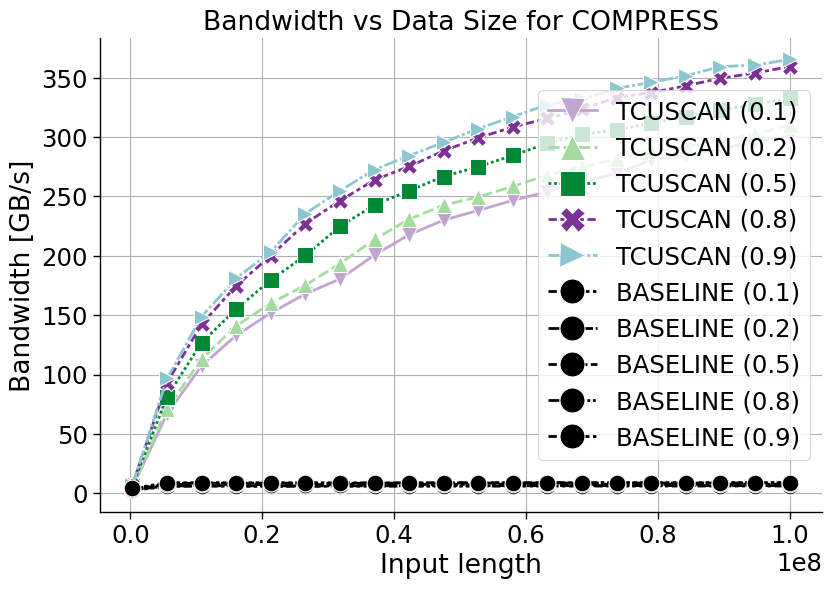

<Figure size 870x627 with 0 Axes>

In [7]:
palette = [### Colorbrewer colors
"#c2a5cf",
"#a6dba0",
"#008837",
"#7b3294",
"#8bc6d1",
"black",
"black",
"black",
"black",
"black",
]

ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)

ax.set_title(f"Bandwidth vs Data Size for COMPRESS")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth [GB/s]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/compress_{dtype}.png")
plt.show()
plt.clf()
